In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

In [3]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import acovf, acf, pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.tsa.arima.model import ARIMA

In [4]:
from pmdarima import auto_arima

In [5]:
from sklearn.metrics import mean_squared_error

In [6]:
import tensorflow as tf

Load the EMHIRES dataset. The dataset includes an offshore wind power production time series from multiple European countries spanning 30 years. 

In [7]:
df = pd.read_csv('data/TS.CF.OFFSHORE.30yr.date.txt', sep='\t', index_col='Date', date_format='%d/%m/%Y %H:%M', parse_dates=True)

In [8]:
df.head()

,Time step,Year,Month,Day,Hour,BE,DK,DE,NL,UK
Date,,,,,,,,,,
1986-01-01 00:00:00,1,1986,1,1,0,0.65206,0.69450,0.64662,0.65980,0.44185
1986-01-01 01:00:00,2,1986,1,1,1,0.60341,0.67387,0.63756,0.64448,0.42026
1986-01-01 02:00:00,3,1986,1,1,2,0.52151,0.65254,0.62826,0.62745,0.38456
1986-01-01 03:00:00,4,1986,1,1,3,0.46460,0.64079,0.62038,0.60343,0.34960
1986-01-01 04:00:00,5,1986,1,1,4,0.41794,0.62641,0.61222,0.57977,0.31395


In [9]:
df.index.freq='h'

In [10]:
df.isnull().sum()

Time step    0
Year         0
Month        0
Day          0
Hour         0
BE           0
DK           0
DE           0
NL           0
UK           0
dtype: int64

Filter the dataset to select Denmark's offshore wind production and resample to monthly frequency

In [11]:
dfm = pd.DataFrame(df['DK'].resample(rule='ME').apply('mean'))

In [12]:
dfm.index.freq = 'ME'

array([[<Axes: title={'center': 'DK'}>]], dtype=object)

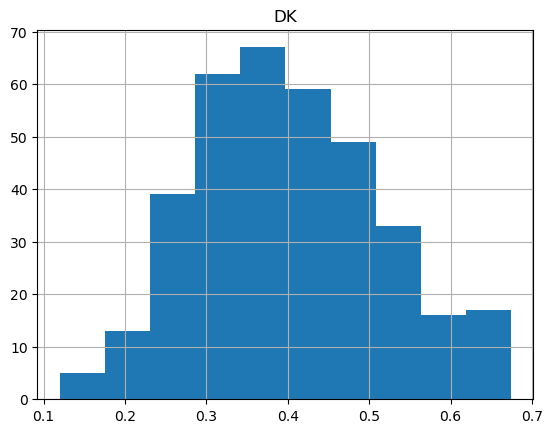

In [13]:
dfm.hist()

Power production exhibits a clear seasonal pattern, with lower output in summer and higher output in winter

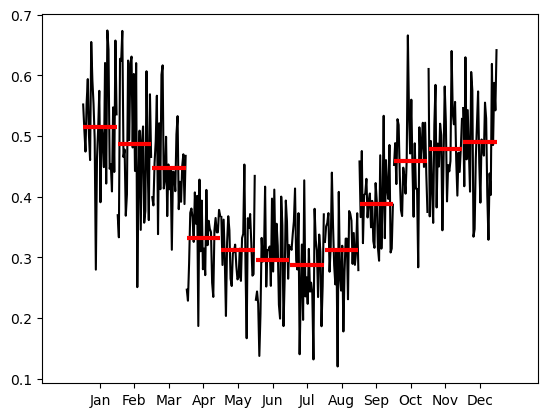

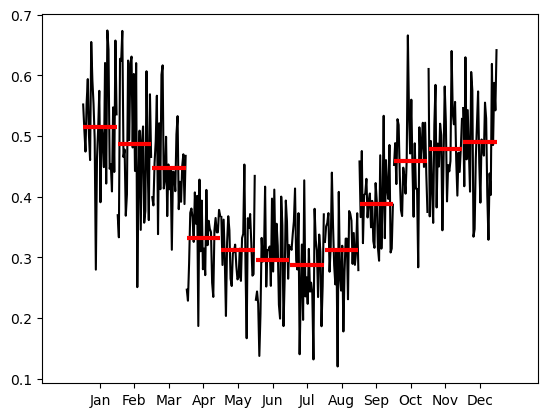

In [14]:
month_plot(dfm)

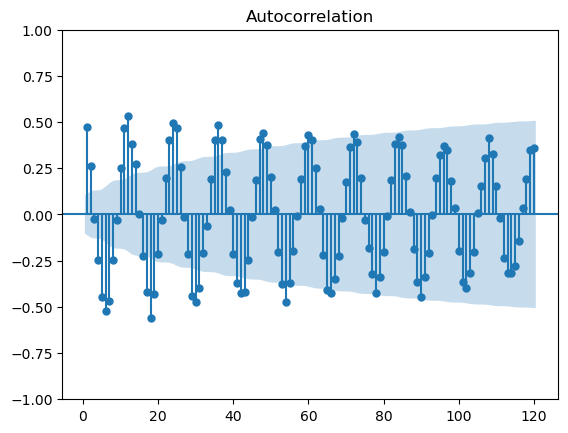

In [15]:
plot_acf(dfm, zero=False, lags=120);

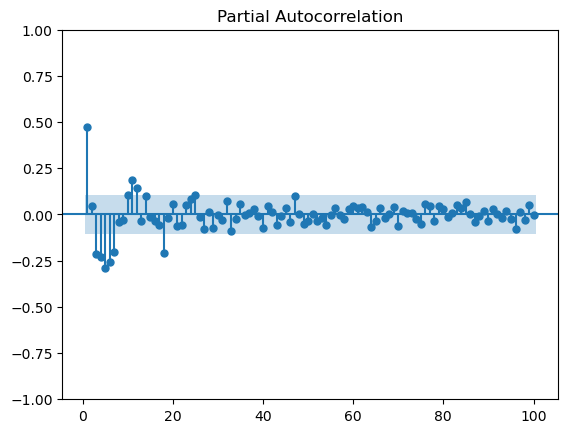

In [16]:
plot_pacf(dfm, zero=False, lags=100);

In [17]:
adfuller(dfm)

(np.float64(-5.237704185122217),
 np.float64(7.3604082962955115e-06),
 17,
 342,
 {'1%': np.float64(-3.4496162602188187),
  '5%': np.float64(-2.870028369720798),
  '10%': np.float64(-2.5712922615505627)},
 np.float64(-727.4877034491185))

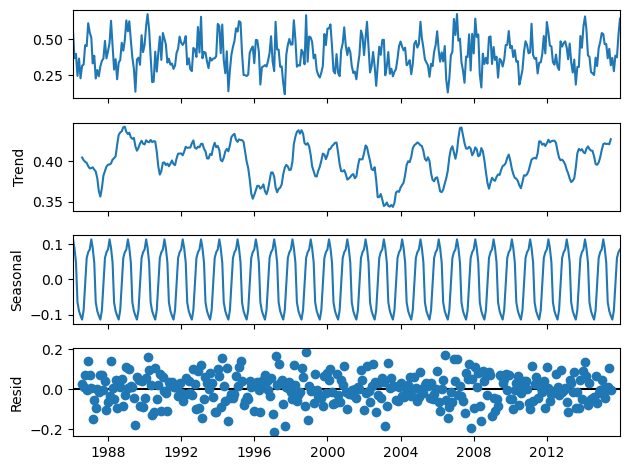

In [18]:
seasonal_decompose(dfm, model='add').plot();

Perform an ARIMA fit on the monthly time series

In [19]:
autofit = auto_arima(dfm, m=12, 
                     start_p=1, start_q=1, max_p=5, max_q=5,
                     start_P=1, start_Q=1, max_P=3, max_Q=3,
                     seasonal=True, trace=True)
autofit.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.96 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=-545.009, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=-687.450, Time=0.63 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=-656.319, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=392.099, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=-636.142, Time=0.13 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=-692.035, Time=2.29 sec
 ARIMA(1,0,0)(3,0,0)[12] intercept   : AIC=inf, Time=6.60 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.70 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.69 sec
 ARIMA(1,0,0)(3,0,1)[12] intercept   : AIC=-758.564, Time=7.48 sec
 ARIMA(1,0,0)(3,0,2)[12] intercept   : AIC=inf, Time=6.45 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.12 sec
 ARIMA(0,0,0)(3,0,1)[12] intercept   : AIC=inf, Time=4.15 sec
 ARIMA(2,0,0)(3,0,1)[12] intercept   : AIC=-758.509, Ti

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  360
Model:             SARIMAX(2, 0, 1)x(3, 0, 1, 12)   Log Likelihood                 391.148
Date:                            Wed, 15 Apr 2026   AIC                           -764.297
Time:                                    21:16:42   BIC                           -729.322
Sample:                                01-31-1986   HQIC                          -750.390
                                     - 12-31-2015                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0032      0.003      0.977      0.329      -0.003       0.009
ar.L1         -0.5920      0.428     -1.382      0.167      -1.432       0.248
ar.L2          0.0966      0.051      1.908      0.056      -0.003       0.196
ma.L1          0.6536      0.433      1.510      0.131      -0.195       1.502
ar.S.L12       0.9705      0.067     14.464      0.000       0.839       1.102
ar.S.L24      -0.0614      0.076     -0.812      0.417      -0.210       0.087
ar.S.L36       0.0857      0.061      1.399      0.162      -0.034       0.206
ma.S.L12      -0.8800      0.054    -16.187      0.000      -0.987      -0.773
sigma2         0.0062      0.000     13.391      0.000       0.005       0.007
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 2.43
Prob(Q):                              0.88   Prob(JB):                         0.30
Heteroskedasticity (H):               0.93   Skew:                             0.01
Prob(H) (two-sided):                  0.70   Kurtosis:                         3.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [20]:
x = int(np.ceil(len(dfm)*0.65))
dfm_train = dfm[0:x]
dfm_test = dfm[x:]

In [21]:
model = ARIMA(dfm_train, order=(2,0,1), seasonal_order=(3,0,1,12))
results = model.fit(method_kwargs={'maxiter':1000})
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                               DK   No. Observations:                  234
Model:             ARIMA(2, 0, 1)x(3, 0, 1, 12)   Log Likelihood                 249.149
Date:                          Wed, 15 Apr 2026   AIC                           -480.298
Time:                                  21:16:49   BIC                           -449.200
Sample:                              01-31-1986   HQIC                          -467.760
                                   - 06-30-2005                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3995      0.027     15.015      0.000       0.347       0.452
ar.L1          0.6695      7.024      0.095      0.924     -13.096      14.435
ar.L2         -0.0517      0.735     -0.070      0.944      -1.491       1.388
ma.L1         -0.5689      7.037     -0.081      0.936     -14.362      13.224
ar.S.L12       1.0415      0.090     11.522      0.000       0.864       1.219
ar.S.L24      -0.0148      0.101     -0.147      0.883      -0.213       0.183
ar.S.L36      -0.0284      0.082     -0.346      0.730      -0.189       0.132
ma.S.L12      -0.9468      0.149     -6.358      0.000      -1.239      -0.655
sigma2         0.0063      0.001      7.327      0.000       0.005       0.008
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 3.34
Prob(Q):                              0.93   Prob(JB):                         0.19
Heteroskedasticity (H):               0.82   Skew:                             0.05
Prob(H) (two-sided):                  0.39   Kurtosis:                         3.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

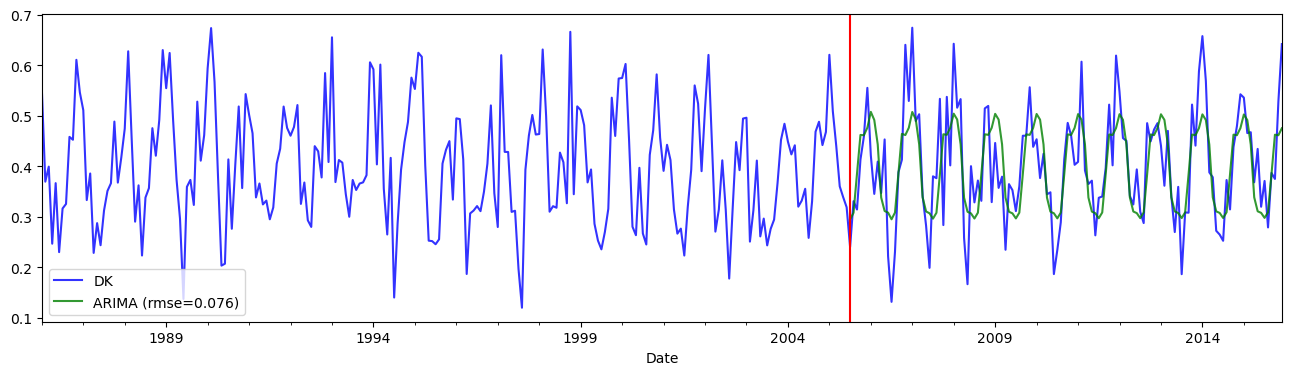

In [22]:
start = len(dfm_train)
end = len(dfm_train)+len(dfm_test)-1
dfm_pred = results.predict(start=start, end=end)
dfm_pred = dfm_pred.rename(f'ARIMA (rmse={np.sqrt(mean_squared_error(dfm_test, dfm_pred)):2.2})')

fig = plt.figure(figsize=(16,4))
ax = plt.gca()

dfm.plot(color='blue', alpha=0.8, ax=ax)
dfm_pred.plot(legend=True, alpha=0.8, color='green', ax=ax)
plt.axvline(dfm_test.index[0], color='red')

Filter the dataset to select Denmark's offshore wind production, resample to hourly frequency and keep only the last month

In [23]:
dfh = pd.DataFrame(df['DK'])
dfh = dfh.tail(24*30) # last month

In [24]:
dfh.index.freq='h'

No clear daily (24 hour) pattern observed, any daily effects are weak or masked by multi-day variability

<Axes: xlabel='Date'>

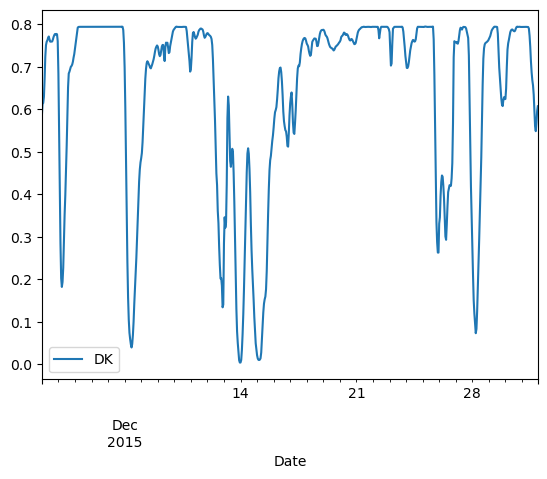

In [25]:
dfh.plot()

In [26]:
adfuller(dfh)

(np.float64(-3.5686928961001287),
 np.float64(0.0063885438459803925),
 14,
 705,
 {'1%': np.float64(-3.4396596024765795),
  '5%': np.float64(-2.86564834926679),
  '10%': np.float64(-2.568957779286756)},
 np.float64(-3915.006066500475))

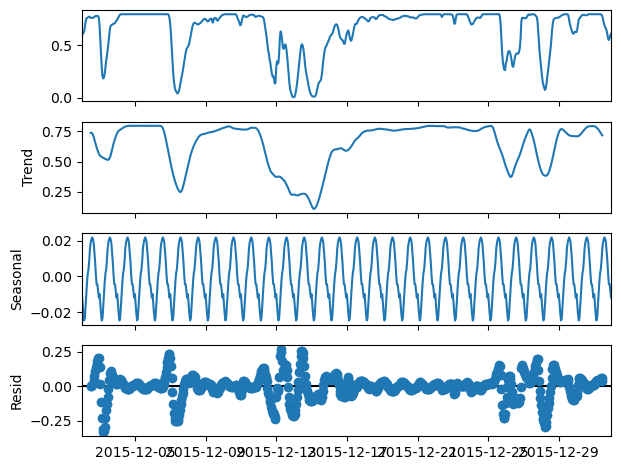

In [27]:
seasonal_decompose(dfh, model='add').plot();

Perform an ARIMA fit on the hourly time series

In [28]:
autofit = auto_arima(dfh, m=24, 
                     start_p=1, start_q=1, max_p=3, max_q=3,
                     start_P=1, start_Q=1, max_P=3, max_Q=3,
                     seasonal=True, trace=True)
autofit.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[24] intercept   : AIC=inf, Time=4.07 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=-160.537, Time=0.07 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=-2985.101, Time=2.48 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=-1162.787, Time=1.64 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=1488.631, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(1,0,0)(2,0,0)[24] intercept   : AIC=-2983.595, Time=94.95 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=2.07 sec
 ARIMA(1,0,0)(0,0,1)[24] intercept   : AIC=-2984.802, Time=1.36 sec
 ARIMA(1,0,0)(2,0,1)[24] intercept   : AIC=inf, Time=60.87 sec
 ARIMA(0,0,0)(1,0,0)[24] intercept   : AIC=-203.153, Time=1.10 sec
 ARIMA(2,0,0)(1,0,0)[24] intercept   : AIC=-3895.953, Time=3.42 sec
 ARIMA(2,0,0)(0,0,0)[24] intercept   : AIC=-3898.062, Time=0.31 sec
 ARIMA(2,0,0)(0,0,1)[24] intercept   : AIC=-3896.062, Time=0.48 sec
 ARIMA(2,0,0)(1,0,1)[24] inter

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  720
Model:               SARIMAX(2, 0, 3)   Log Likelihood                2022.103
Date:                Wed, 15 Apr 2026   AIC                          -4030.205
Time:                        21:20:51   BIC                          -3998.150
Sample:                    12-02-2015   HQIC                         -4017.830
                         - 12-31-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0097      0.002      4.772      0.000       0.006       0.014
ar.L1          1.7773      0.036     50.025      0.000       1.708       1.847
ar.L2         -0.7924      0.036    -22.082      0.000      -0.863      -0.722
ma.L1          0.4361      0.042     10.311      0.000       0.353       0.519
ma.L2         -0.0453      0.046     -0.976      0.329      -0.136       0.046
ma.L3         -0.1307      0.034     -3.888      0.000      -0.197      -0.065
sigma2         0.0002   4.88e-06     43.188      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):              8087.97
Prob(Q):                              0.80   Prob(JB):                         0.00
Heteroskedasticity (H):               2.49   Skew:                            -0.93
Prob(H) (two-sided):                  0.00   Kurtosis:                        19.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
x = int(np.ceil(len(dfh)*0.65))
dfh_train = dfh[0:x]
dfh_test = dfh[x:]

In [30]:
model = ARIMA(dfh_train, order=(2,0,3), seasonal_order=(0,0,0,24))
results = model.fit(method_kwargs={'maxiter':1000})
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                     DK   No. Observations:                  468
Model:                 ARIMA(2, 0, 3)   Log Likelihood                1326.989
Date:                Wed, 15 Apr 2026   AIC                          -2639.979
Time:                        21:20:52   BIC                          -2610.940
Sample:                    12-02-2015   HQIC                         -2628.552
                         - 12-21-2015                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6205      0.096      6.480      0.000       0.433       0.808
ar.L1          1.7546      0.043     40.626      0.000       1.670       1.839
ar.L2         -0.7688      0.044    -17.360      0.000      -0.856      -0.682
ma.L1          0.5283      0.055      9.620      0.000       0.421       0.636
ma.L2         -0.0342      0.055     -0.627      0.531      -0.141       0.073
ma.L3         -0.1090      0.032     -3.411      0.001      -0.172      -0.046
sigma2         0.0002   5.43e-06     36.525      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):              7283.02
Prob(Q):                              0.85   Prob(JB):                         0.00
Heteroskedasticity (H):               0.41   Skew:                            -1.10
Prob(H) (two-sided):                  0.00   Kurtosis:                        22.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

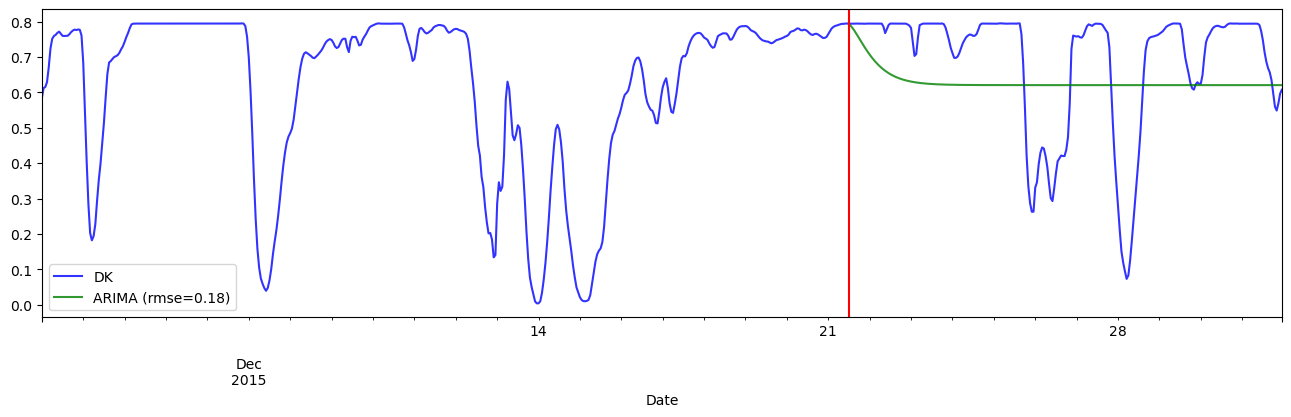

In [31]:
start = len(dfh_train)
end = len(dfh_train)+len(dfh_test)-1
dfh_pred = results.predict(start=start, end=end)
dfh_pred = dfh_pred.rename(f'ARIMA (rmse={np.sqrt(mean_squared_error(dfh_test, dfh_pred)):2.2})')

fig = plt.figure(figsize=(16,4))
ax = plt.gca()

dfh.plot(color='blue', alpha=0.8, ax=ax)
dfh_pred.plot(legend=True, alpha=0.8, color='green', ax=ax)
plt.axvline(dfh_test.index[0], color='red')

Prepare TimeseriesGenerator and create LSTM model to forecast next month power from the previous 12 months

In [32]:
tsg = tf.keras.preprocessing.sequence.TimeseriesGenerator

In [33]:
train = np.array(dfm_train['DK'])
test = np.array(dfm_test['DK'])

In [34]:
mytsg = tsg(train, train, length=12, batch_size=1) # predict next month from previous year

In [35]:
mytsg[0]

(array([[0.55208547, 0.36956693, 0.39925734, 0.24684551, 0.36662692,
         0.23014688, 0.3164895 , 0.32547079, 0.45816385, 0.45244267,
         0.61058789, 0.54622247]]),
 array([0.51084015]))

In [36]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(12,1)))
model.add(tf.keras.layers.LSTM(64, return_sequences=True, activation='relu'))
model.add(tf.keras.layers.LSTM(32))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='mse')

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Train the LSTM model

In [38]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='loss',patience=10,restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='loss',factor=0.5,patience=5,min_lr=1e-6)
model.fit(mytsg, epochs=100, callbacks=[reduce_lr, early_stop])

Epoch 1/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0163 - learning_rate: 0.0010
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0147 - learning_rate: 0.0010
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0124 - learning_rate: 0.0010
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0141 - learning_rate: 0.0010
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0128 - learning_rate: 0.0010
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0082 - learning_rate: 0.0010
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0074 - learning_rate: 0.0010
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0071 - learning_rate: 0.0010
Epoch 9/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0077 - learning_rate: 0.0010
Epoch 10/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0085 - learning_rate: 0.0010
Epoch 11/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0068 - learn

Epoch 64/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0062 - learning_rate: 3.9063e-06
Epoch 65/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0059 - learning_rate: 1.9531e-06
Epoch 66/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0062 - learning_rate: 1.9531e-06
Epoch 67/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0066 - learning_rate: 1.9531e-06
Epoch 68/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0065 - learning_rate: 1.9531e-06
Epoch 69/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0067 - learning_rate: 1.9531e-06
Epoch 70/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0073 - learning_rate: 1.0000e-06
Epoch 71/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0062 - learning_rate: 1.0000e-06
Epoch 72/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0051 - learning_rate: 1.0000e-06
Epoch 73/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0061 - learning_rate: 1.0000e-06
Epoch 74/100
222/222 ━━━━━━━━

Test the trained LSTM model

In [39]:
model.predict(train[-12:].reshape(1,12,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step


array([[0.29101864]], dtype=float32)

In [40]:
test[0]

np.float64(0.24033326612903227)

In [41]:
predictions = []

batch = train[-12:].reshape((1, 12, 1))

for i in range(len(test)):
    prediction = model.predict(batch)[0]
    predictions.append(prediction) 
    batch = np.append(batch[:,1:,:],[[prediction]],axis=1)
    
dfm_pred = pd.DataFrame(predictions, index=dfm_test.index, columns=["LSTM"])
dfm_pred = dfm_pred["LSTM"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

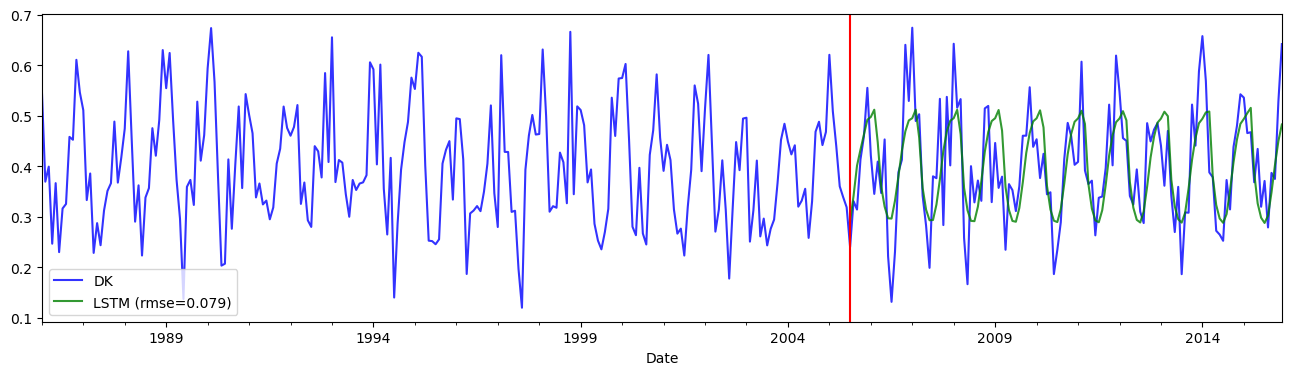

In [42]:
start = len(dfm_train)
end = len(dfm_train)+len(dfm_test)-1

dfm_pred = dfm_pred.rename(f'LSTM (rmse={np.sqrt(mean_squared_error(dfm_test, dfm_pred)):2.2})')

fig = plt.figure(figsize=(16,4))
ax = plt.gca()

dfm.plot(color='blue', alpha=0.8, ax=ax)
dfm_pred.plot(legend=True, alpha=0.8, color='green', ax=ax)
plt.axvline(dfm_test.index[0], color='red')

Prepare TimeseriesGenerator and create LSTM model to forecast next hour power from the previous 3 days

In [43]:
dfh = pd.DataFrame(df['DK'])
dfh = dfh.tail(24*30) # last month
dfh.index.freq='h'
x = int(np.ceil(len(dfh)*0.65))
dfh_train = dfh[0:x]
dfh_test = dfh[x:]

In [44]:
tsg = tf.keras.preprocessing.sequence.TimeseriesGenerator

In [45]:
train = np.array(dfh_train['DK'])
test = np.array(dfh_test['DK'])

In [46]:
mytsg = tsg(train, train, length=24*3, batch_size=1) # predict next hour from previous 3 days

In [47]:
mytsg[0]

(array([[0.58345, 0.61239, 0.61505, 0.62925, 0.67083, 0.72388, 0.75116,
         0.75917, 0.76247, 0.76794, 0.77153, 0.76554, 0.75959, 0.75931,
         0.75971, 0.75988, 0.76442, 0.77036, 0.7747 , 0.77731, 0.77607,
         0.77755, 0.77675, 0.76065, 0.68426, 0.54749, 0.40331, 0.28411,
         0.20261, 0.18215, 0.19379, 0.22725, 0.29263, 0.35176, 0.39766,
         0.45452, 0.51417, 0.58582, 0.6522 , 0.68446, 0.68858, 0.69476,
         0.70009, 0.70215, 0.70547, 0.71203, 0.72198, 0.73026, 0.74279,
         0.7563 , 0.76787, 0.78163, 0.79214, 0.79402, 0.79428, 0.79428,
         0.79428, 0.79428, 0.79429, 0.79428, 0.79428, 0.79429, 0.79429,
         0.79428, 0.79425, 0.79423, 0.79421, 0.79431, 0.79425, 0.79429,
         0.79428, 0.79427]]),
 array([0.79428]))

In [48]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(24*3,1)))
model.add(tf.keras.layers.LSTM(128, return_sequences=True, activation='relu'))
model.add(tf.keras.layers.LSTM(64))
model.add(tf.keras.layers.Dense(32, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='mse')

In [49]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 72, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

Train the LSTM model

In [50]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='loss',patience=10,restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='loss',factor=0.5,patience=5,min_lr=1e-6)
model.fit(mytsg, epochs=100, callbacks=[reduce_lr, early_stop])

Epoch 1/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0353 - learning_rate: 0.0010
Epoch 2/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 0.0069 - learning_rate: 0.0010
Epoch 3/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - loss: 0.0030 - learning_rate: 0.0010
Epoch 4/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 0.0023 - learning_rate: 0.0010
Epoch 5/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 0.0024 - learning_rate: 0.0010
Epoch 6/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - loss: 0.0016 - learning_rate: 0.0010
Epoch 7/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - loss: 0.0015 - learning_rate: 0.0010
Epoch 8/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - loss: 9.9828e-04 - learning_rate: 0.0010
Epoch 9/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 7.1625e-04 - learning_rate: 0.0010
Epoch 10/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - loss: 9.9534e-04 - learning_rate: 0.0010
Epoch 11/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 18s 4

Test the trained LSTM model

In [51]:
model.predict(train[-24*3:].reshape(1,24*3,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step


array([[0.7909139]], dtype=float32)

In [52]:
test[0]

np.float64(0.79399)

In [53]:
predictions = []

batch = train[-24*3:].reshape((1, 24*3, 1))

for i in range(len(test)):
    prediction = model.predict(batch)[0]
    predictions.append(prediction) 
    batch = np.append(batch[:,1:,:],[[prediction]],axis=1)
    
dfh_pred = pd.DataFrame(predictions, index=dfh_test.index, columns=["LSTM"])
dfh_pred = dfh_pred["LSTM"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


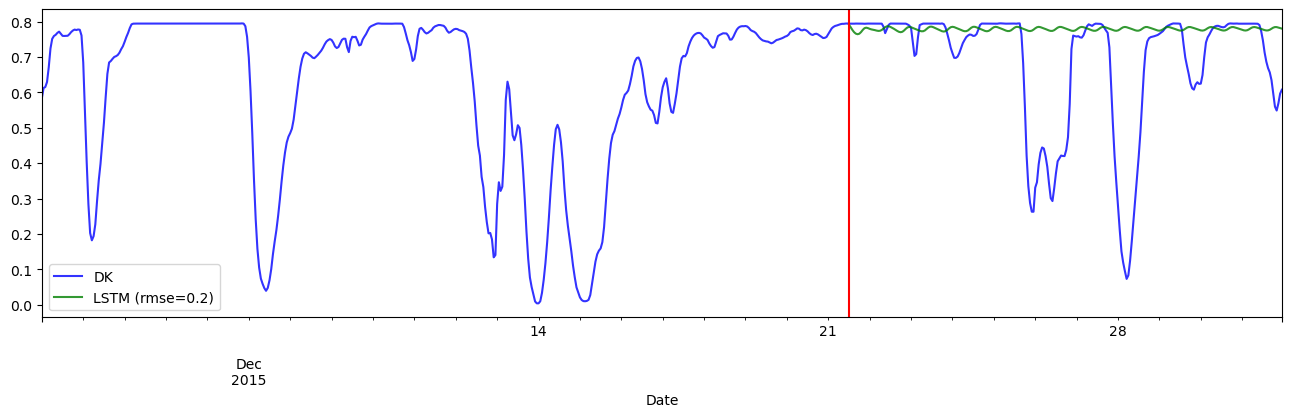

In [54]:
start = len(dfh_train)
end = len(dfh_train)+len(dfh_test)-1

dfh_pred = dfh_pred.rename(f'LSTM (rmse={np.sqrt(mean_squared_error(dfh_test, dfh_pred)):2.2})')

fig = plt.figure(figsize=(16,4))
ax = plt.gca()

dfh.plot(color='blue', alpha=0.8, ax=ax)
dfh_pred.plot(legend=True, alpha=0.8, color='green', ax=ax)
plt.axvline(dfh_test.index[0], color='red')